In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt


Initial angles: [0.1 0.1]
Step  5: Angles = [0.35397398 0.35397398], Signal Metric = -0.0885
Step 10: Angles = [0.98957953 0.98957953], Signal Metric = -0.5144
Step 15: Angles = [1.44804408 1.44804408], Signal Metric = -0.7253
Step 20: Angles = [1.54917376 1.54917376], Signal Metric = -0.7360


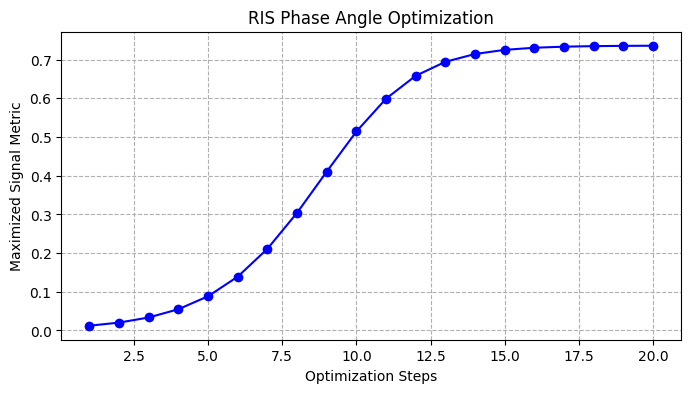


Optimized Stepup Complete
Final Optimized RIS angles : [1.54917376 1.54917376]


In [2]:
#Defining the 2D coordinates for the drone,car and 2 mirrors
drone = np.array([0.0,0.5])   #Static source
car = np.array([10.0,0.0])    #Static destination
ris1 = np.array([4.0,6.0])    #Mirror 1
ris2 = np.array([7.0,5.0])    #Mirror 2

#Setting up a 2 qubit quantum device for 2 mirrors
dev = qml.device("default.qubit",wires = 2)

#Defining the quantum circuit
@qml.qnode(dev)
def quantum_signal_circuit(angles):
    #Creating a superposition
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)

    #Mapping spacial coordinates to initial quantum states
    qml.RY(drone[1], wires=0)
    qml.RY(car[0],wires=1)

    #Applying the RIS mirror reflection phases 
    qml.RZ(angles[0], wires=0)
    qml.RZ(angles[1], wires=1)

    #Entangling the qubits/paths to simulate interference at the receiver(car)
    qml.CNOT(wires=[0,1])
    qml.Hadamard(wires=0)

    #Measuring the expected signal output
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

#Finding the best mirror adjustments (Optimization)
#Starting with random mirror phase angles
angles = np.array([0.1,0.1],requires_grad = True)
opt= qml.GradientDescentOptimizer(stepsize=0.4)

#Storing history for plotting 
history_steps = []
history_signal = []


print(f'Initial angles: {angles}')

for step in range(20):
     #We want to find the maximum value, but since the Descent Optimizer finds the lowest value, we use the negative sign
     angles = opt.step(lambda a: -quantum_signal_circuit(a),angles)

     if (step+1) % 5 == 0:
          #Printing results after every 5 steps
          print(f"Step {step+1:2d}: Angles = {angles}, Signal Metric = {-quantum_signal_circuit(angles):.4f}")
     #Recording the current signal metric 
     current_signal= quantum_signal_circuit(angles)
     history_steps.append(step+1)
     history_signal.append(current_signal)

#Plotting
plt.figure(figsize=(8,4))
plt.plot(history_steps,history_signal,marker='o',color='b',linestyle='-')
plt.title("RIS Phase Angle Optimization")
plt.xlabel("Optimization Steps")
plt.ylabel("Maximized Signal Metric")
plt.grid(True,linestyle ='--')
plt.show()
          
print("\nOptimized Stepup Complete")
print(f"Final Optimized RIS angles : {angles}")